In [1]:
!pip install imbalanced-learn

In [ ]:
import os
import glob
import time
import numpy as np
import pandas as pd
import seaborn as sns
import datetime as dt
import tensorflow as tf
import matplotlib.pyplot as plt

from joblib import dump, load
from os import path
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from matplotlib.pyplot import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

In [3]:
# full dataset
# path = "swb-s3926387-personal-study"
path = r'C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV'
all_files = glob.glob(path + "/*.csv")
li = []
for filename in all_files:
    df = pd.read_csv(filename, encoding='cp1252', index_col=None, header=0)
    li.append(df)
    print("Read Completed for ", filename)
df = pd.concat(li, axis=0, ignore_index=True)
df.describe()
df.head()
df.info()

Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged01.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged02.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged03.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged04.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged05.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged06.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged07.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-2023/MERGED_CSV\Merged08.csv
Read Completed for  C:/Users/ADMIN/Desktop/code_folders/Capstone_Project/CIC-IDS/CSV-202

In [4]:
print(df.columns)
print(df["Label"].value_counts())
print(df.shape)

Index(['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate',
       'fin_flag_number', 'syn_flag_number', 'rst_flag_number',
       'psh_flag_number', 'ack_flag_number', 'ece_flag_number',
       'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count',
       'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP',
       'DHCP', 'ARP', 'ICMP', 'IGMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max',
       'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Variance', 'Label'],
      dtype='object')
Label
DDOS-ICMP_FLOOD            6893259
DDOS-UDP_FLOOD             5181027
DDOS-TCP_FLOOD             4306086
DDOS-PSHACK_FLOOD          3920372
DDOS-SYN_FLOOD             3886130
DDOS-RSTFINFLOOD           3872808
DDOS-SYNONYMOUSIP_FLOOD    3445659
DOS-UDP_FLOOD              3177323
DOS-TCP_FLOOD              2558256
DOS-SYN_FLOOD              1942176
BENIGN                     1051373
MIRAI-GREETH_FLOOD          949381
MIRAI-UDPPLAIN              852695
MIRAI-GREIP_FLOOD   

Many network intrusion datasets (like CICIoT2023) contain very specific attack names (e.g., 'DDoS-UDP_Flood', 'SqlInjection'). These are too granular for efficient model training and analysis, so we group them into broader categories, such as 'DDoS', 'DoS', 'Recon', etc.

<h3> Why this is useful </h3>
    <li> Reduces label complexity (from 30+ labels to ~6–7 categories).</li>
    <li> Helps balance the dataset more evenly.</li>
    <li> Simplifies the classification problem for your ML model.</li>

<h3> Example: </h3>
<p>If your original data had this:</p>
<P>Label</p>
<ul>
    <li>DDoS-UDP_Flood</li>
    <li>DDoS-ACK_Fragmentation</li>
    <li>SqlInjection</li>
</ul>

<p>It will become:</p>
<p>Label</p>
<ul>
    <li>DDoS</li>
    <li>DDoS</li>
    <li>Web_based</li>
</ul>

In [5]:
DDoS = ['DDOS-ACK_FRAGMENTATION',     
        'DDOS-UDP_FLOOD',       
        'DDOS-SLOWLORIS',               
        'DDOS-ICMP_FLOOD',        
        'DDOS-RSTFINFLOOD',    
        'DDOS-PSHACK_FLOOD',        
        'DDOS-HTTP_FLOOD',              
        'DDOS-UDP_FRAGMENTATION',     
        'DDOS-TCP_FLOOD',  
        'DDOS-SYN_FLOOD',        
        'DDOS-SYNONYMOUSIP_FLOOD',    
        'DDOS-ICMP_FRAGMENTATION']

DoS = ['DOS-UDP_FLOOD',    
       'DOS-TCP_FLOOD',    
       'DOS-SYN_FLOOD',    
       'DOS-HTTP_FLOOD']

Spoofing = ['MITM-ARPSPOOFING',     
            'DNS_SPOOFING']

Brute_force = ['DICTIONARYBRUTEFORCE']

Recon = ['RECON-HOSTDISCOVERY', 
         'RECON-OSSCAN',     
         'RECON-PORTSCAN',               
         'RECON-PINGSWEEP',         
         'VULNERABILITYSCAN']

Web_based = ['SQLINJECTION',        
             'BROWSERHIJACKING',         
             'COMMANDINJECTION',       
             'XSS',         
             'BACKDOOR_MALWARE',          
             'UPLOADING_ATTACK']

Mirai = ['MIRAI-GREETH_FLOOD',     
         'MIRAI-UDPPLAIN',     
         'MIRAI-GREIP_FLOOD']



def classify_attacks(data):
    data['Label'].replace(DDoS,'DDoS',inplace=True)
    data['Label'].replace(DoS,'DoS',inplace=True)
    data['Label'].replace(Spoofing,'Spoofing',inplace=True)
    data['Label'].replace(Brute_force,'Brute_Force',inplace=True)
    data['Label'].replace(Recon,'Recon',inplace=True)
    data['Label'].replace(Web_based,'Web_based',inplace=True)
    data['Label'].replace(Mirai,'Mirai',inplace=True)
classify_attacks(df)

print(df["Label"].value_counts())
print(df.shape)

Label
DDoS           32536197
DoS             7746554
Mirai           2521731
BENIGN          1051373
Recon            661121
Spoofing         465937
Web_based         23799
Brute_Force       12522
Name: count, dtype: int64
(45019243, 40)


In [6]:
df

,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,19.92,6,63.36,25893.962218,0.0,0.00,0.0,0.99,0.99,0.0,...,6421.0,60.0,481.0,64.21,42.100000,64.21,0.000039,100.0,1772.410000,DDoS
1,0.00,47,64.00,3703.841331,0.0,0.00,0.0,0.00,0.00,0.0,...,57320.0,98.0,578.0,573.20,48.000000,573.20,0.000271,100.0,2304.000000,Mirai
2,7.92,17,65.91,19673.095685,0.0,0.00,0.0,0.00,0.00,0.0,...,6010.0,60.0,70.0,60.10,1.000000,60.10,0.000057,100.0,1.000000,DoS
3,20.40,6,110.50,261.664826,0.1,0.00,0.3,0.20,0.40,0.0,...,2223.0,54.0,1500.0,222.30,451.596686,222.30,0.004766,10.0,203939.566667,Spoofing
4,0.32,1,63.96,28944.199848,0.0,0.00,0.0,0.00,0.01,0.0,...,6006.0,60.0,66.0,60.06,0.600000,60.06,0.000035,100.0,0.360000,DDoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45019238,20.00,6,64.00,33267.005076,0.0,1.00,0.0,0.00,0.00,0.0,...,6000.0,60.0,60.0,60.00,0.000000,60.00,0.000030,100.0,0.000000,DDoS
45019239,20.00,6,64.00,8280.792087,0.0,1.00,0.0,0.00,0.00,0.0,...,6000.0,60.0,60.0,60.00,0.000000,60.00,0.000121,100.0,0.000000,DDoS
45019240,20.00,6,64.00,31939.567469,0.0,0.00,0.0,0.00,0.00,0.0,...,6000.0,60.0,60.0,60.00,0.000000,60.00,0.000033,100.0,0.000000,DDoS
45019241,8.24,17,65.55,3334.661589,0.0,0.01,0.0,0.00,0.00,0.0,...,6075.0,60.0,90.0,60.75,3.934758,60.75,0.000300,100.0,15.482323,DDoS


Non-numerical data is incomprehensible to machine learning modules. To avoid issues later on, the data should be arranged numerically. The answer to this problem is to convert all text values to numerical form.

In [7]:
data_clean = df.dropna().reset_index(drop=True)
data_clean.drop_duplicates(keep='first', inplace = True)

data_clean.replace([np.inf, -np.inf], np.nan, inplace=True) # Replace inf and -inf with NaN, then drop the resulting NaNs
data_clean.dropna(inplace=True)

data_clean['Label'].value_counts()
print("Read {} rows.".format(len(data_clean)))

data_clean.columns          # This just lists the column names in the data_clean DataFrame—helpful for debugging or inspection.
data_clean = data_clean.dropna().reset_index()    # dropna() removes any rows that contain NaN (missing) values; reset_index() resets the row index after dropping, so it's clean and continuous.
data_clean['Label'].value_counts()     # Shows how many samples exist for each class (now as numbers). This is useful to check for class imbalance.
print(data_clean.shape)
print(data_clean['Label'].value_counts())

Read 20833013 rows.
(20833013, 41)
Label
DDoS           12122114
DoS             4178464
Mirai           2359183
BENIGN          1047308
Recon            654062
Spoofing         435662
Web_based         23700
Brute_Force       12520
Name: count, dtype: int64


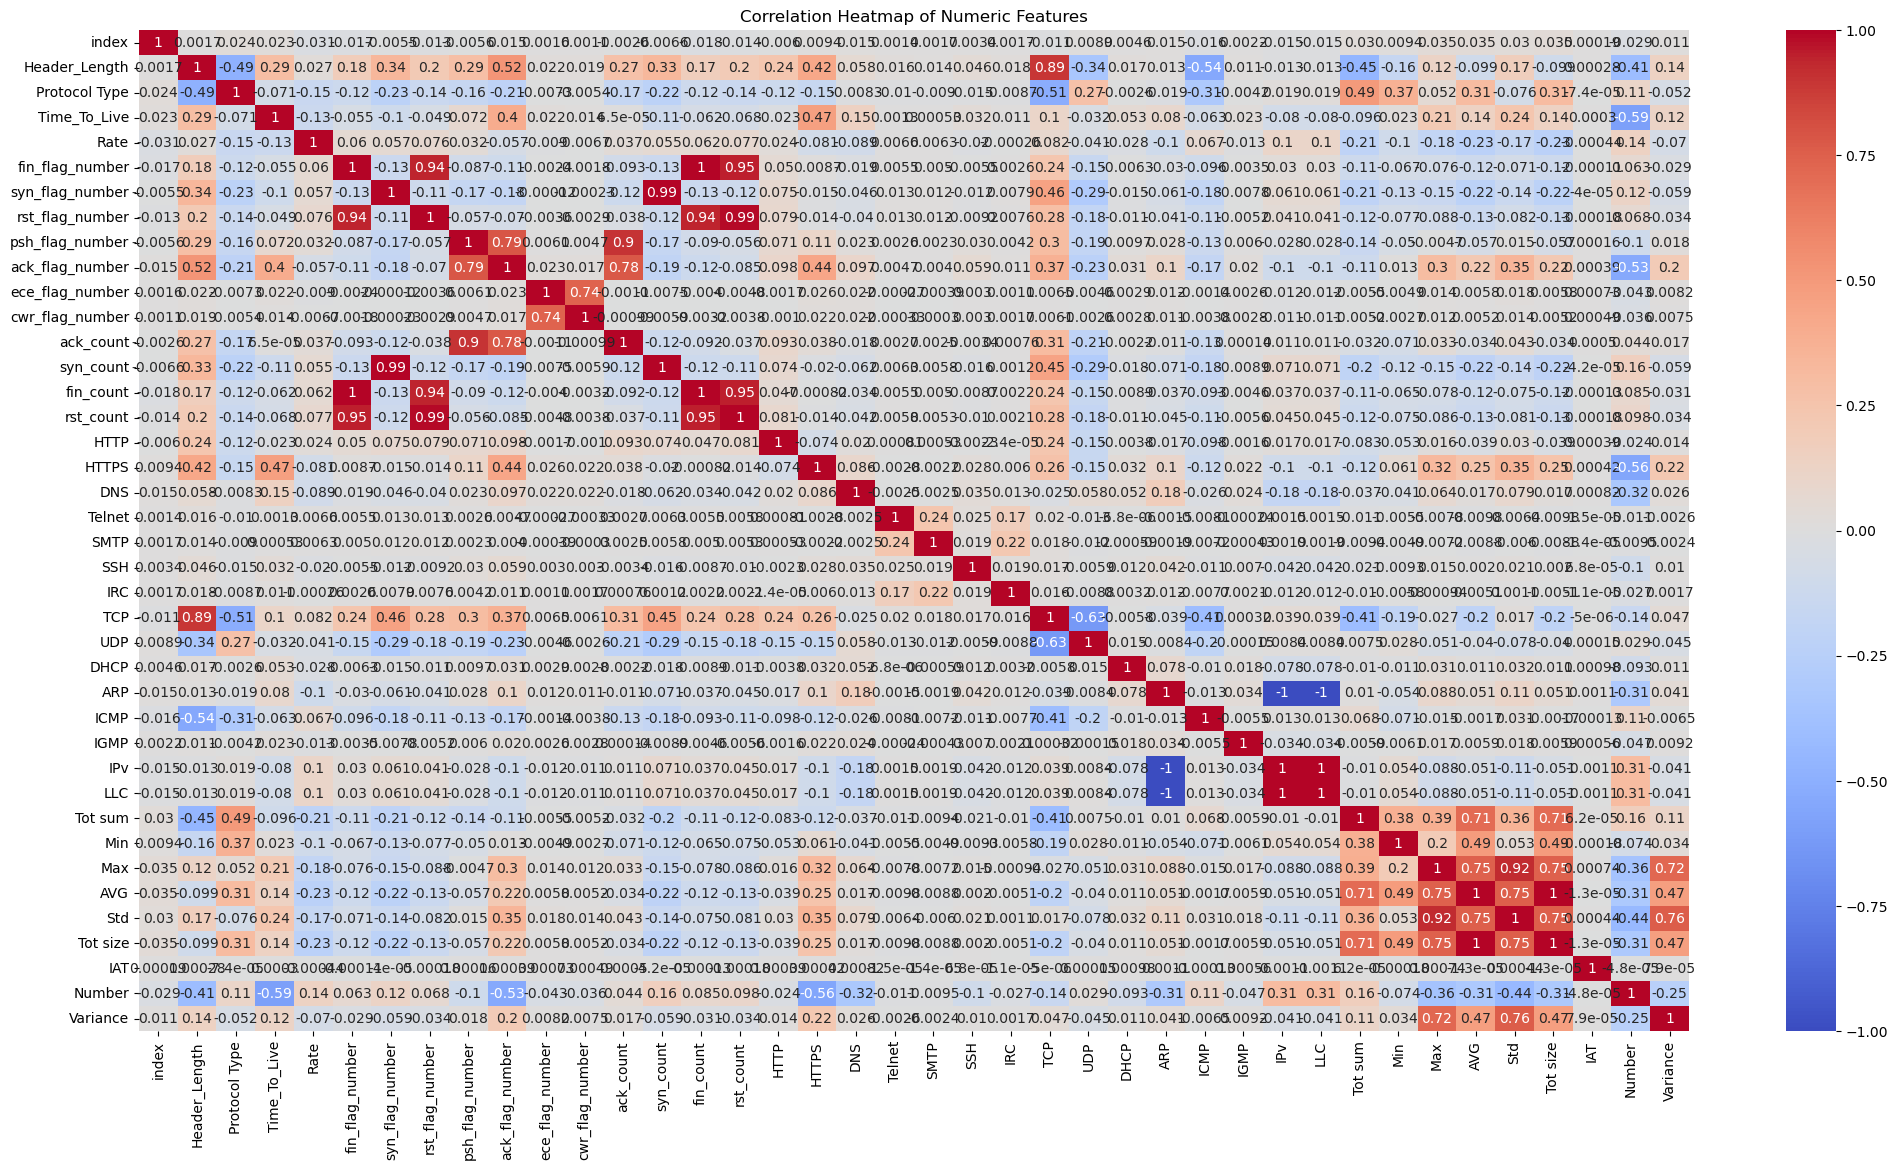

In [8]:
# Before correlation filter
# Select only numeric columns for correlation
numeric_data = data_clean.select_dtypes(include=['number'])

plt.figure(figsize=(25, 13))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [9]:
data_clean = data_clean.drop(columns=['index', 'fin_count', 'rst_count', 'Tot size', 'syn_count', 'ack_count', 'Std', 'Header_Length'])

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Features')

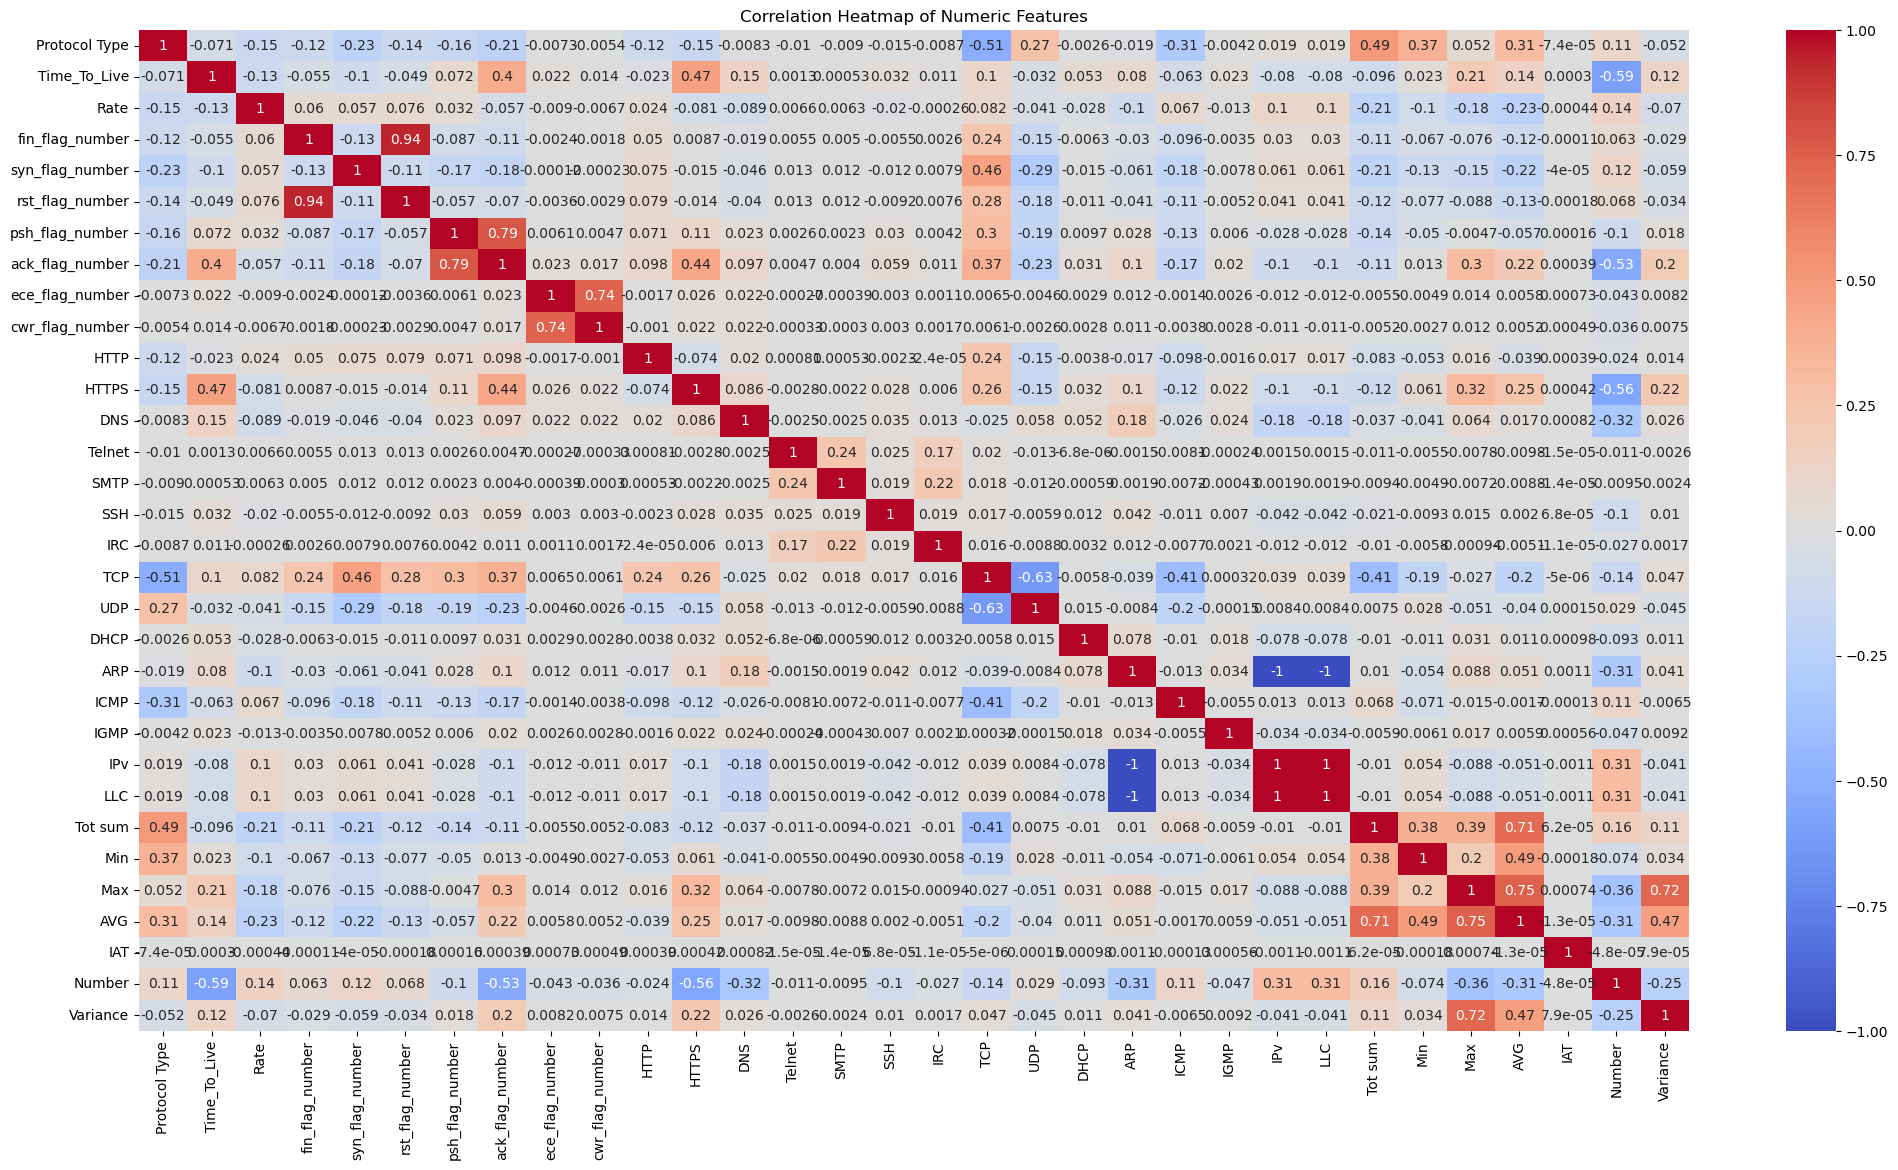

In [10]:
# After correlation filter
# Select only numeric columns for correlation
numeric_data = data_clean.select_dtypes(include=['number'])

plt.figure(figsize=(25, 13))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Features")

In [11]:
# columns_name = data_clean.drop(columns=['Label']).columns

In [12]:
# data_np = data_clean.to_numpy(dtype="float32")      # Converts the entire DataFrame into a NumPy array with float32 data type—faster and more efficient for ML model input.
# #drop inf values
#data_clean = data_clean[~np.isinf(data_clean).any(axis=1)]   # Removes any rows that have infinite values (inf) across any column. This ensures clean numeric data for training

In [13]:
# Dataset check
# for i in range(100):
#     print(data_clean['index'][i])


In [14]:
rows = data_clean.shape[0]
limit = round(rows*50/100) # split the dataset into 2 part: 80% for train and val; 20% to test
train_val = data_clean[1:limit] 	

test = data_clean[limit:rows]

In [15]:
print(train_val.shape)
# print(train_val['Label'].value_counts())

(10416505, 33)


In [16]:
# X = train_val[:, :-1] 
# Y = train_val[:, -1]

In [17]:
X = train_val.drop(columns=['Label'])
Y = train_val['Label']

In [18]:
print(Y.shape)
print(X.shape)

(10416505,)
(10416505, 32)


In [ ]:
# Unbalance handling

# Under sampling
undersample = RandomUnderSampler(sampling_strategy={'DDoS':1123843, 'DoS':1123843}) # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
                                                                            # the target undersample - in this case '2' is the name of the 'DDOS' after encoded
X_under, y_under = undersample.fit_resample(X, Y)

# Over sampling
sm = SMOTE()
X_sm, Y_sm = sm.fit_resample(X_under, y_under)

print(Y_sm.shape)
print(X_sm.shape)

(8990776,)
(8990776, 32)


In [20]:
# Under sampling only
# undersample = RandomUnderSampler(sampling_strategy='all')   # if the strategy ='all' - normal undersample; if it a dict then the key is the name of the label and the value is 
#                                                             # the target undersample - in this case '2' is the name of the 'DDOS' after encoded
# X_sm, Y_sm = undersample.fit_resample(X, Y)

In [21]:
# This block is created to keep track with the under or over sampling

label_series = pd.Series(Y) # data_np is numPy type so it need to revert back to DataFrame to use value_counts
print(label_series.value_counts())

Label
DDoS           6200508
DoS            2079992
Mirai          1123843
BENIGN          487094
Recon           304803
Spoofing        203429
Web_based        11015
Brute_Force       5821
Name: count, dtype: int64


In [22]:
X_test = test.drop(columns=['Label'])
Y_test = test['Label']

What it does:
This scales (standardizes) your feature matrix X.
Specifically:
<ul>
    <li>StandardScaler() creates an object that standardizes the features.
    <li>Standardization means: for each feature/column in X, it will subtract the mean and divide by the standard deviation.
</ul>
Mathematically for each feature:

𝑋_scaled = (𝑋 − mean(𝑋)) / std(𝑋)
 
As a result:
<ul>
    <li>The new mean of each feature = 0.
    <li>The new standard deviation of each feature = 1.
</ul>

Why StandardScale important?
<ul>
    <li>Machine Learning algorithms (especially neural networks) work better when input features are on the same scale.
    <li>If features have very different scales (e.g., some from 0–1, some from 0–10,000), the model can struggle to converge or be biased toward features with larger numbers.
    <li>Standardization makes gradient descent faster and model training more stable.
</ul>

In simple terms:
<ul>
    <li>Before: your features might look like [50, 10000, 3.2, 0.001]
    <li>After StandardScaler: numbers become something like [0.12, 2.5, -1.0, -0.3]
    <li>Now all features are centered around 0 and have similar ranges, which helps the model learn better!
</ul>

In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sm)

In [24]:
# Split the data set into training and testing
X_train, X_val, Y_train, Y_val = train_test_split(
    X_scaled, Y_sm, test_size=0.25, random_state=33, shuffle=True)

_features = X_sm.shape[1]  # _features stores how many input features there are (i.e., the number of columns in X).
n_classes = Y_sm.shape  # n_classes stores how many output classes there are (i.e., how many unique categories in Y after one-hot encoding).

In [25]:
print(_features)
print(n_classes)

32
(8990776,)


<h2>Logisitc Regression<h2>

In [46]:
# Train model
logis_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
logis_model.fit(X_train, Y_train)

y_pred_logis = logis_model.predict(X_val)

In [47]:
print(classification_report(Y_val, y_pred_logis))

              precision    recall  f1-score   support

      BENIGN       0.47      0.56      0.51    281262
 Brute_Force       0.77      0.48      0.59    280980
        DDoS       0.87      0.60      0.71    280918
         DoS       0.69      0.91      0.79    280575
       Mirai       1.00      1.00      1.00    281617
       Recon       0.57      0.51      0.54    280827
    Spoofing       0.46      0.56      0.50    281260
   Web_based       0.42      0.45      0.44    280255

    accuracy                           0.63   2247694
   macro avg       0.66      0.63      0.63   2247694
weighted avg       0.66      0.63      0.63   2247694



In [44]:
print(Y_test)

10416506     DDoS
10416507    Mirai
10416508    Recon
10416509    Mirai
10416510      DoS
            ...  
20833008      DoS
20833009     DDoS
20833010     DDoS
20833011     DDoS
20833012      DoS
Name: Label, Length: 10416507, dtype: object


In [48]:
for i in range(50):
    sample = X_test.iloc[[i]]  # Make it 2D by using double brackets
    pred = logis_model.predict(sample)
    actual = Y_test.iloc[i]

    print(f"Sample {i}: Predicted = {pred[0]}, Actual = {actual}")


Sample 0: Predicted = Mirai, Actual = DDoS
Sample 1: Predicted = Mirai, Actual = Mirai
Sample 2: Predicted = DDoS, Actual = Recon
Sample 3: Predicted = Mirai, Actual = Mirai
Sample 4: Predicted = Mirai, Actual = DoS
Sample 5: Predicted = Mirai, Actual = DDoS
Sample 6: Predicted = Mirai, Actual = DoS
Sample 7: Predicted = Mirai, Actual = DDoS
Sample 8: Predicted = DDoS, Actual = BENIGN
Sample 9: Predicted = DDoS, Actual = DDoS
Sample 10: Predicted = Mirai, Actual = DDoS
Sample 11: Predicted = Mirai, Actual = DoS
Sample 12: Predicted = DDoS, Actual = DDoS
Sample 13: Predicted = Mirai, Actual = DDoS
Sample 14: Predicted = Mirai, Actual = DDoS
Sample 15: Predicted = Mirai, Actual = DDoS
Sample 16: Predicted = Mirai, Actual = DDoS
Sample 17: Predicted = Mirai, Actual = DoS
Sample 18: Predicted = Mirai, Actual = DoS
Sample 19: Predicted = DDoS, Actual = DDoS
Sample 20: Predicted = Mirai, Actual = DDoS
Sample 21: Predicted = Mirai, Actual = Mirai
Sample 22: Predicted = DDoS, Actual = DDoS
Sam

c:\Users\ADMIN\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ADMIN\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ADMIN\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ADMIN\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ADMIN\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\ADMIN\anaconda3\lib\site-packages\sklearn\utils\validation.py:2732: Use

In [ ]:
import pickle

# Save the model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(frst_model, f)
    
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(labelencoder, f)

<h4>KFold method for Random Forest model<h4>

In [ ]:
folds = 5  # Define the number of folds for K-fold cross-validation

kf = KFold(n_splits=folds, shuffle=True, random_state=42)  # Initialize the KFold object

for train_index, test_index in kf.split(X_train):
    # Split the dataset into training and testing sets for this fold
    X_frst_train_fold, X_frst_test_fold = X_train[train_index], X_train[test_index]
    y_frst_train_fold, y_frst_test_fold = Y_train[train_index], Y_train[test_index]
    
    # Define the model
    frst_model_fold = RandomForestClassifier(n_estimators=15, max_depth=10, min_samples_split=200, min_samples_leaf=200)
    
    # Train the model on the training data
    frst_model_fold.fit(X_frst_train_fold, y_frst_train_fold)

    # Make predictions on the test data
    y_frst_pred_fold = frst_model_fold.predict(X_frst_test_fold)

    # Calculate score for this fold
    print('Accuracy score: %.2f' % accuracy_score(y_frst_test_fold, y_frst_pred_fold))
    print('Precision score: %.2f' % precision_score(y_frst_test_fold, y_frst_pred_fold, average='weighted'))
    print('Recall score: %.2f' % recall_score(y_frst_test_fold, y_frst_pred_fold, average='weighted'))
    print('F1 score: %.2f' % f1_score(y_frst_test_fold, y_frst_pred_fold, average='weighted'))
    print("\n")

In [ ]:
frst_model_fold.fit(X_train, Y_train)

y_pred_frst_model_fold = frst_model_fold.predict(X_val)

In [ ]:
print('Accuracy score: %.2f' % accuracy_score(Y_val, y_pred_frst))
print('Precision score: %.2f' % precision_score(Y_val, y_pred_frst, average='weighted'))
print('Recall score: %.2f' % recall_score(Y_val, y_pred_frst, average='weighted'))
print('F1 score: %.2f' % f1_score(Y_val, y_pred_frst, average='weighted'))